In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from typing import Tuple
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
from scipy.signal import savgol_coeffs, freqz

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
def filt_freq_resp(
    fs: float,
    filt_window_duration: float,
    filt_poly: int,
    deriv: int = 0
) -> Tuple[npt.NDArray]:
    
    filt_window = int(fs * filt_window_duration)
    filt_window = filt_window if filt_window % 2 != 0 else filt_window + 1

    filt_coeffs = savgol_coeffs(
        window_length=filt_window,
        polyorder=filt_poly,
        deriv=deriv,
        use='dot'
    )

    w, h = freqz(filt_coeffs, worN=2048) # w: normalized frequencies [rad/sample], h: complex response

    f_hz = (w * fs) / (2 * np.pi)
    mag = np.abs(h)
    if deriv == 0: # for derivative filters, keep magnitude linear
        mag = 20 * np.log10(mag) # convert to dB
    phase = np.degrees(np.unwrap(np.angle(h)))

    return f_hz, mag, phase


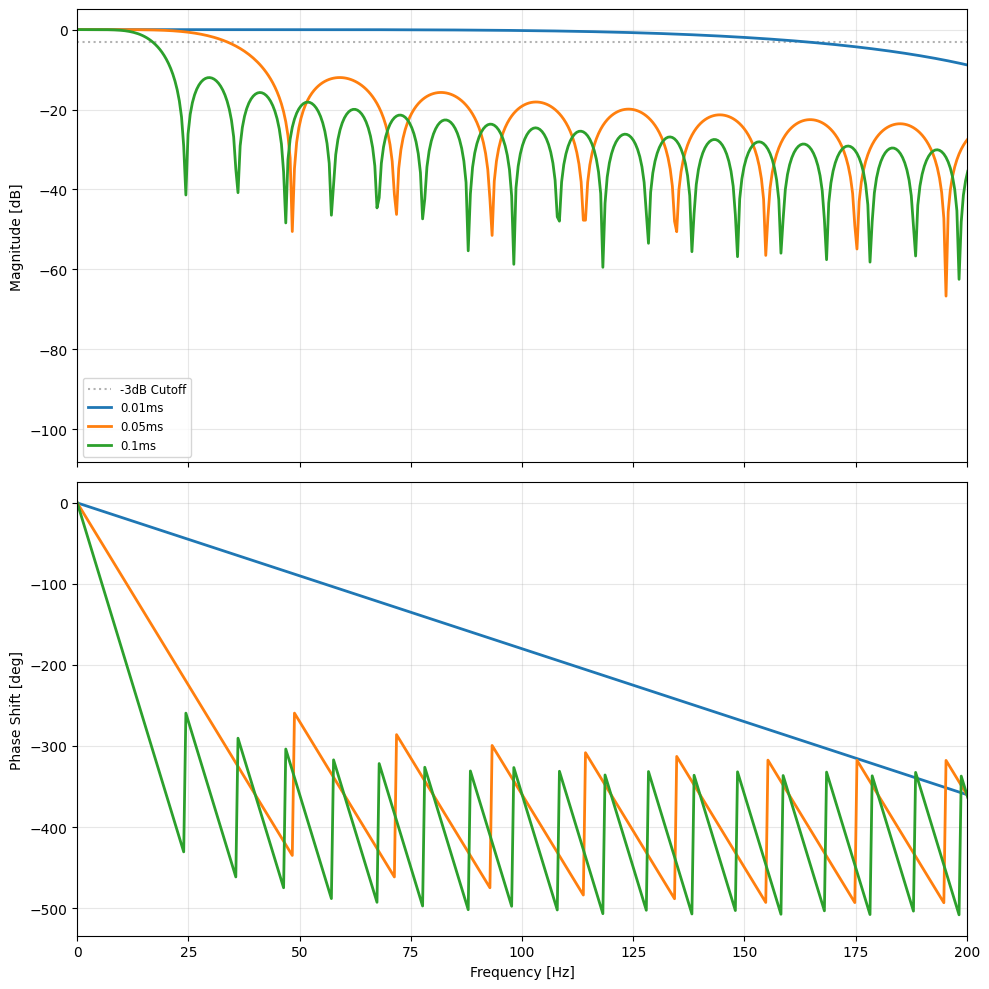

In [8]:
filt_window_duration = [0.01, 0.05, 0.1]

fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10,10), sharex=True)
ax_mag.axhline(-3, color='k', ls=':', alpha=0.3, label='-3dB Cutoff')

for dur in filt_window_duration:

    f_hz, mag, phase =  filt_freq_resp(
        fs = 2000,
        filt_window_duration=dur,
        filt_poly=4
    )
    ax_mag.plot(f_hz, mag, linewidth=2, label=f"{dur:.03}ms")
    ax_phase.plot(f_hz, phase, linewidth=2, label=f"{dur:.03}ms")

ax_mag.set_ylabel('Magnitude [dB]')
ax_mag.grid(True, which='both', alpha=0.3)
ax_mag.legend(loc='lower left', fontsize='small')
ax_phase.set_ylabel('Phase Shift [deg]')
ax_phase.set_xlabel('Frequency [Hz]')
ax_phase.set_xlim(0, 200)
ax_phase.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()